# RSNN Load Forecasting: Pecan Street

Recurrent spiking network (recurrent connections in both spiking layers) that
predicts the **change** in grid load for the next 15-minute step.

Carried over from the SNN v2 script:
- Delta (residual) target, reconstructed to absolute grid units for metrics
- Learnable membrane decay (`learn_beta=True`)
- Per-home embedding
- Magnitude-weighted Huber loss
- Gap-aware windowing
- Early stopping on validation RMSE (absolute units)

New in this version:
- Recurrent connections in both spiking layers
- Expanded 13-feature input set (solar, refrigerator, car, water heater, dryer, dishwasher)
- Lazy windowing: windows are sliced on the fly instead of copied up front
- Persistence baseline reported next to the model
- All plots rendered inline only (nothing written to disk)

## 1. Imports

In [1]:
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import snntorch as snn

## 2. Config

In [7]:
CSV_PATH = "/home/ahaandesai/Dev/FYP/data/15minute_data_austin/15minute_data_austin.csv"   # <-- set this

SEED = 42

WINDOW = 96          # 24 hours at 15-minute resolution
HORIZON = 1          # predict next 15-minute interval
STEP_SECONDS = 15 * 60

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

BATCH_SIZE = 256
EPOCHS = 40
PATIENCE = 6         # early stopping, in epochs with no val-RMSE improvement
LR = 1e-3
WEIGHT_DECAY = 1e-4

HIDDEN1 = 64
HIDDEN2 = 32
BETA_INIT = 0.90
DROPOUT = 0.15
REC_INIT_GAIN = 0.5  # orthogonal init gain for recurrent weights (keeps activity stable early on)

HOME_EMBED_DIM = 4

# Weighted Huber: weight = 1 + PEAK_WEIGHT_ALPHA * |scaled target delta|
PEAK_WEIGHT_ALPHA = 2.0

# 0 is the safe choice inside Jupyter (multiprocessing workers can hang on Windows/macOS).
# Windowing is lazy and cheap now, so workers are rarely needed.
NUM_WORKERS = 0

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

FEATURES = [
    "grid",
    "air1",
    "furnace1",
    "solar",
    "refrigerator1",
    "car1",
    "waterheater1",
    "drye1",
    "dishwasher1",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

TARGET = "grid"

# Raw measurement columns (everything that is not a calendar feature).
RAW_COLS = [f for f in FEATURES if f not in TIME_FEATURES]

# Columns a home must have at >= MIN_COVERAGE to be kept. The other columns
# (solar, car1, ...) are optional: many homes simply don't own that device,
# so a missing column is treated as "0 W" instead of dropping the home.
REQUIRED_COLS = ["grid", "air1", "furnace1"]
MIN_COVERAGE = 0.90

# Appliance channels are non-negative. Grid can be negative (export), and
# solar's sign convention varies by export, so neither is clipped at zero.
NONNEG_COLS = [c for c in RAW_COLS if c not in ("grid", "solar")]

# Columns that get train-only quantile outlier bounds (everything but grid).
BOUND_COLS = [c for c in RAW_COLS if c != "grid"]

RESULTS_DIR = Path("results/rsnn")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 3. Reproducibility and device

In [3]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Device: cuda


## 4. Data cleaning and home selection

In [4]:
def clean_home(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["local_15min"] = pd.to_datetime(df["local_15min"], errors="coerce", utc=True)

    df = df.dropna(subset=["local_15min"])
    df = df.sort_values("local_15min")
    df = df.drop_duplicates("local_15min")

    for col in RAW_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in NONNEG_COLS:
        df.loc[df[col] < 0, col] = np.nan

    local_time = df["local_15min"].dt.tz_convert("America/Chicago")

    hour = local_time.dt.hour + local_time.dt.minute / 60.0
    dow = local_time.dt.dayofweek

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)

    return df


def coverage(df: pd.DataFrame, col: str) -> float:
    return df[col].notna().mean()


def prepare_homes(raw: pd.DataFrame):

    homes = []

    for dataid, home in raw.groupby("dataid"):

        home = clean_home(home)

        if len(home) < WINDOW + HORIZON + 100:
            continue
        if any(coverage(home, c) < MIN_COVERAGE for c in REQUIRED_COLS):
            continue

        homes.append((dataid, home))

    print(f"Homes retained: {len(homes)}")

    for dataid, home in homes:
        cov = " | ".join(f"{c}={coverage(home, c):.0%}" for c in RAW_COLS)
        print(f"  {dataid}: {len(home):,} rows | {cov}")

    return homes


def get_train_bounds(train_parts):

    combined = pd.concat(train_parts, ignore_index=True)

    bounds = {}
    for col in BOUND_COLS:
        s = combined[col].dropna()
        if len(s) == 0:
            continue  # column absent everywhere; nothing to bound
        bounds[col] = (float(s.quantile(0.001)), float(s.quantile(0.999)))

    return bounds


def apply_cleaning_and_imputation(df, bounds):

    df = df.copy()

    for col, (lo, hi) in bounds.items():
        df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

    for col in RAW_COLS:
        df[col] = df[col].interpolate(method="linear", limit=4, limit_direction="both")

    for col in RAW_COLS:
        if col != "grid":
            df[col] = df[col].fillna(0.0)

    df = df.dropna(subset=["grid"])

    return df


def build_home_index(homes):
    return {dataid: idx for idx, (dataid, _) in enumerate(homes)}

## 5. Load CSV and select homes

In [8]:
raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Loaded {len(raw):,} rows")

homes = prepare_homes(raw)
if not homes:
    raise RuntimeError("No homes satisfy the coverage requirements.")

home_to_idx = build_home_index(homes)
num_homes = len(home_to_idx)

Loaded 873,286 rows
Homes retained: 15
  661: 35,032 rows | grid=99% | air1=98% | furnace1=92% | solar=99% | refrigerator1=92% | car1=97% | waterheater1=0% | drye1=74% | dishwasher1=92%
  1642: 34,648 rows | grid=99% | air1=99% | furnace1=97% | solar=99% | refrigerator1=97% | car1=76% | waterheater1=0% | drye1=29% | dishwasher1=97%
  2335: 34,468 rows | grid=100% | air1=97% | furnace1=100% | solar=100% | refrigerator1=100% | car1=100% | waterheater1=0% | drye1=100% | dishwasher1=97%
  2818: 34,980 rows | grid=100% | air1=92% | furnace1=100% | solar=100% | refrigerator1=100% | car1=0% | waterheater1=0% | drye1=0% | dishwasher1=100%
  3456: 34,932 rows | grid=100% | air1=100% | furnace1=100% | solar=100% | refrigerator1=100% | car1=0% | waterheater1=0% | drye1=55% | dishwasher1=100%
  6139: 35,036 rows | grid=100% | air1=100% | furnace1=100% | solar=100% | refrigerator1=0% | car1=87% | waterheater1=0% | drye1=78% | dishwasher1=88%
  7536: 34,984 rows | grid=100% | air1=100% | furnace1=10

## 6. Chronological split, train-only cleaning and scaling

In [9]:
train_homes, val_homes, test_homes = [], [], []

for dataid, home in homes:
    n = len(home)
    train_end = int(n * TRAIN_FRAC)
    val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

    train_homes.append((dataid, home.iloc[:train_end].copy()))
    val_homes.append((dataid, home.iloc[train_end:val_end].copy()))
    test_homes.append((dataid, home.iloc[val_end:].copy()))

bounds = get_train_bounds([df for _, df in train_homes])

print("Train-only outlier bounds:")
for col, (lo, hi) in bounds.items():
    print(f"  {col}: {lo:.4f} -> {hi:.4f}")

train_homes = [(d, apply_cleaning_and_imputation(df, bounds)) for d, df in train_homes]
val_homes = [(d, apply_cleaning_and_imputation(df, bounds)) for d, df in val_homes]
test_homes = [(d, apply_cleaning_and_imputation(df, bounds)) for d, df in test_homes]


def _steps_since_start(df):
    t = df["local_15min"].dt.tz_convert(None)
    return ((t - t.iloc[0]) / pd.Timedelta(seconds=STEP_SECONDS)).to_numpy()


def collect_train_deltas(homes):
    """Raw HORIZON-step grid deltas from the train split (gap-aware),
    used only to fit the delta target scaler."""
    deltas = []
    for _, df in homes:
        grid = df[TARGET].to_numpy(dtype=np.float32)
        steps = _steps_since_start(df)
        d = grid[HORIZON:] - grid[:-HORIZON]
        contiguous = np.isclose(steps[HORIZON:] - steps[:-HORIZON], HORIZON)
        deltas.append(d[contiguous])
    return np.concatenate(deltas).reshape(-1, 1)


feature_scaler = StandardScaler()
delta_scaler = StandardScaler()

feature_scaler.fit(pd.concat([df[FEATURES] for _, df in train_homes], ignore_index=True))

train_deltas = collect_train_deltas(train_homes)
delta_scaler.fit(train_deltas)

print(
    f"\nTrain delta stats: mean={train_deltas.mean():.4f}, "
    f"std={train_deltas.std():.4f}"
)

Train-only outlier bounds:
  air1: 0.0000 -> 3.9619
  furnace1: 0.0020 -> 2.7951
  solar: -0.0320 -> 4.9759
  refrigerator1: 0.0010 -> 0.5300
  car1: 0.0000 -> 3.4000
  waterheater1: 0.0000 -> 2.6618
  drye1: 0.0000 -> 4.5586
  dishwasher1: 0.0000 -> 1.1390

Train delta stats: mean=-0.0001, std=1.1729


## 7. Dataset (lazy windows, delta target, gap-aware)

In [10]:
class WindowDataset(Dataset):
    """Stores each split once as one contiguous array and slices windows on the fly.
    A window is kept only if it spans exactly the expected elapsed time,
    so no window crosses a gap left by dropped rows."""

    def __init__(self, homes, feature_scaler, delta_scaler, home_to_idx):

        x_parts, grid_parts, end_parts, hidx_parts = [], [], [], []
        offset = 0

        for dataid, df in homes:

            n = len(df)
            if n < WINDOW + HORIZON:
                continue

            x_parts.append(feature_scaler.transform(df[FEATURES]).astype(np.float32))
            grid_parts.append(df[TARGET].to_numpy(dtype=np.float32))

            steps = _steps_since_start(df)

            ends = np.arange(WINDOW, n - HORIZON + 1)
            tgt = ends + HORIZON - 1

            # Input window + target step must span exactly (WINDOW + HORIZON - 1) steps.
            ok = np.isclose(steps[tgt] - steps[ends - WINDOW], WINDOW + HORIZON - 1)
            ends = ends[ok]

            end_parts.append(ends + offset)
            hidx_parts.append(np.full(len(ends), home_to_idx[dataid], dtype=np.int64))
            offset += n

        self.X = np.concatenate(x_parts)
        self.grid = np.concatenate(grid_parts)
        self.ends = np.concatenate(end_parts)
        self.home_idx = np.concatenate(hidx_parts)

        last = self.grid[self.ends - 1]
        target = self.grid[self.ends + HORIZON - 1]

        self.last_raw = last.astype(np.float32)
        self.y = delta_scaler.transform((target - last).reshape(-1, 1)).reshape(-1).astype(np.float32)

        print(f"Dataset: {len(self.ends):,} sequences (gap-crossing windows excluded)")

    def __len__(self):
        return len(self.ends)

    def __getitem__(self, i):
        end = self.ends[i]
        return (
            torch.from_numpy(self.X[end - WINDOW:end]),
            torch.tensor(self.y[i], dtype=torch.float32),
            torch.tensor(self.last_raw[i], dtype=torch.float32),
            torch.tensor(self.home_idx[i], dtype=torch.long),
        )


train_dataset = WindowDataset(train_homes, feature_scaler, delta_scaler, home_to_idx)
val_dataset = WindowDataset(val_homes, feature_scaler, delta_scaler, home_to_idx)
test_dataset = WindowDataset(test_homes, feature_scaler, delta_scaler, home_to_idx)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

Dataset: 359,862 sequences (gap-crossing windows excluded)
Dataset: 75,187 sequences (gap-crossing windows excluded)
Dataset: 77,070 sequences (gap-crossing windows excluded)


## 8. Model: recurrent SNN

Each spiking layer receives its feed-forward input plus a learned projection of
**its own spikes from the previous timestep** (`cur = W_in x_t + W_rec s_{t-1}`).
The readout stays a non-spiking leaky integrator with learnable decay.

In [11]:
class RSNNRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        num_homes,
        hidden1=HIDDEN1,
        hidden2=HIDDEN2,
        beta_init=BETA_INIT,
        home_embed_dim=HOME_EMBED_DIM,
        dropout=DROPOUT,
        rec_gain=REC_INIT_GAIN,
    ):
        super().__init__()

        self.home_embedding = nn.Embedding(num_homes, home_embed_dim)

        fused_input_size = input_size + home_embed_dim
        spike_grad = snn.surrogate.fast_sigmoid()

        # Layer 1 (recurrent)
        self.fc1 = nn.Linear(fused_input_size, hidden1)
        self.rec1 = nn.Linear(hidden1, hidden1, bias=False)
        self.lif1 = snn.Leaky(beta=beta_init, learn_beta=True, spike_grad=spike_grad)
        self.drop1 = nn.Dropout(dropout)

        # Layer 2 (recurrent)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.rec2 = nn.Linear(hidden2, hidden2, bias=False)
        self.lif2 = snn.Leaky(beta=beta_init, learn_beta=True, spike_grad=spike_grad)
        self.drop2 = nn.Dropout(dropout)

        # Non-spiking leaky readout
        self.fc3 = nn.Linear(hidden2, 1)
        self.readout = snn.Leaky(
            beta=beta_init, learn_beta=True, reset_mechanism="none", output=True
        )

        nn.init.orthogonal_(self.rec1.weight, gain=rec_gain)
        nn.init.orthogonal_(self.rec2.weight, gain=rec_gain)

    def forward(self, x, home_idx):

        B, T, _ = x.shape

        home_vec = self.home_embedding(home_idx)                 # (B, E)
        home_vec = home_vec.unsqueeze(1).expand(-1, T, -1)       # (B, T, E)
        x = torch.cat([x, home_vec], dim=-1)

        h1 = self.fc1.out_features
        h2 = self.fc2.out_features

        mem1 = torch.zeros(B, h1, device=x.device)
        mem2 = torch.zeros(B, h2, device=x.device)
        mem3 = torch.zeros(B, 1, device=x.device)
        spk1 = torch.zeros(B, h1, device=x.device)
        spk2 = torch.zeros(B, h2, device=x.device)

        for t in range(T):

            cur1 = self.fc1(x[:, t, :]) + self.rec1(spk1)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(self.drop1(spk1)) + self.rec2(spk2)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc3(self.drop2(spk2))
            _, mem3 = self.readout(cur3, mem3)

        # Predicted (scaled) delta for the next step.
        return mem3.squeeze(-1)


model = RSNNRegressor(input_size=len(FEATURES), num_homes=num_homes).to(device)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {params:,}")

Trainable parameters: 8,448


In [12]:
def report_betas(model, title="Membrane decay (beta)"):
    """Prints each layer's beta (clamped to [0, 1], as snnTorch applies it)
    and the implied membrane time constant tau = -1 / ln(beta) in timesteps."""
    rows = []
    for name, lif in [("lif1", model.lif1), ("lif2", model.lif2), ("readout", model.readout)]:
        beta = lif.beta.detach().cpu().clamp(0.0, 1.0).flatten()
        for i, b in enumerate(beta.tolist()):
            tau = -1.0 / math.log(b) if 0.0 < b < 1.0 else float("inf")
            rows.append({
                "layer": name if len(beta) == 1 else f"{name}[{i}]",
                "beta": b,
                "tau (steps)": tau,
                "tau (minutes)": tau * STEP_SECONDS / 60.0,
            })
    print(title)
    display(pd.DataFrame(rows).round(4))


report_betas(model, "Initial beta values")

Initial beta values


,layer,beta,tau (steps),tau (minutes)
0,lif1,0.9,9.4912,142.3683
1,lif2,0.9,9.4912,142.3683
2,readout,0.9,9.4912,142.3683


## 9. Loss, training and evaluation helpers

In [13]:
def weighted_huber(pred, target, delta=1.0, alpha=PEAK_WEIGHT_ALPHA):
    """Huber loss with per-sample weight that grows with target magnitude,
    so large transitions aren't drowned out by many small near-zero ones."""
    err = pred - target
    abs_err = err.abs()
    quadratic = torch.clamp(abs_err, max=delta)
    linear = abs_err - quadratic
    base = 0.5 * quadratic ** 2 + delta * linear

    weight = 1.0 + alpha * target.abs()
    return (base * weight).mean()


def train_one_epoch(model, loader, optimizer, device):

    model.train()
    total_loss = 0.0

    for X, y, _, home_idx in loader:

        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        home_idx = home_idx.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred = model(X, home_idx)
        loss = weighted_huber(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(X)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict(model, loader, delta_scaler, device):
    """Returns (actual_abs, pred_abs, last_observed) in raw grid units."""

    model.eval()

    pred_deltas, actual_deltas, last_raws = [], [], []

    for X, y, last_raw, home_idx in loader:

        X = X.to(device, non_blocking=True)
        home_idx = home_idx.to(device, non_blocking=True)

        pred = model(X, home_idx)

        pred_deltas.append(pred.cpu().numpy())
        actual_deltas.append(y.numpy())
        last_raws.append(last_raw.numpy())

    pred_deltas = np.concatenate(pred_deltas)
    actual_deltas = np.concatenate(actual_deltas)
    last_raws = np.concatenate(last_raws)

    pred_deltas_raw = delta_scaler.inverse_transform(pred_deltas.reshape(-1, 1)).reshape(-1)
    actual_deltas_raw = delta_scaler.inverse_transform(actual_deltas.reshape(-1, 1)).reshape(-1)

    return last_raws + actual_deltas_raw, last_raws + pred_deltas_raw, last_raws


def calculate_metrics(actuals, preds):
    return {
        "MAE": float(mean_absolute_error(actuals, preds)),
        "RMSE": float(math.sqrt(mean_squared_error(actuals, preds))),
        "R2": float(r2_score(actuals, preds)),
    }

## 10. Train with early stopping

In [14]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

history = {"epoch": [], "train_loss": [], "val_mae": [], "val_rmse": [], "val_r2": [], "lr": []}

best_val = float("inf")
best_state = None
epochs_since_improvement = 0

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    val_actuals, val_preds, _ = predict(model, val_loader, delta_scaler, device)
    val_metrics = calculate_metrics(val_actuals, val_preds)

    scheduler.step(val_metrics["RMSE"])
    lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_mae"].append(val_metrics["MAE"])
    history["val_rmse"].append(val_metrics["RMSE"])
    history["val_r2"].append(val_metrics["R2"])
    history["lr"].append(lr)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | Loss {train_loss:.5f} | "
        f"Val MAE {val_metrics['MAE']:.4f} | Val RMSE {val_metrics['RMSE']:.4f} | "
        f"Val R² {val_metrics['R2']:.4f} | LR {lr:.2e}"
    )

    if val_metrics["RMSE"] < best_val - 1e-5:
        best_val = val_metrics["RMSE"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01/40 | Loss 1.76790 | Val MAE 0.6298 | Val RMSE 1.0084 | Val R² 0.5908 | LR 1.00e-03
Epoch 02/40 | Loss 1.51422 | Val MAE 0.6468 | Val RMSE 0.9651 | Val R² 0.6252 | LR 1.00e-03
Epoch 03/40 | Loss 1.26959 | Val MAE 0.6496 | Val RMSE 0.9730 | Val R² 0.6191 | LR 1.00e-03
Epoch 04/40 | Loss 1.16326 | Val MAE 0.6074 | Val RMSE 0.9390 | Val R² 0.6452 | LR 1.00e-03
Epoch 05/40 | Loss 1.08798 | Val MAE 0.5988 | Val RMSE 0.9287 | Val R² 0.6529 | LR 1.00e-03
Epoch 06/40 | Loss 1.04985 | Val MAE 0.6127 | Val RMSE 0.9323 | Val R² 0.6503 | LR 1.00e-03
Epoch 07/40 | Loss 1.01428 | Val MAE 0.5820 | Val RMSE 0.9073 | Val R² 0.6687 | LR 1.00e-03
Epoch 08/40 | Loss 0.99167 | Val MAE 0.5970 | Val RMSE 0.9350 | Val R² 0.6482 | LR 1.00e-03
Epoch 09/40 | Loss 0.97785 | Val MAE 0.6139 | Val RMSE 0.9561 | Val R² 0.6321 | LR 1.00e-03
Epoch 10/40 | Loss 0.96142 | Val MAE 0.6137 | Val RMSE 0.9340 | Val R² 0.6490 | LR 1.00e-03
Epoch 11/40 | Loss 0.94717 | Val MAE 0.6050 | Val RMSE 0.9260 | Val R² 0.6549 | 

### Learned beta values (best-validation checkpoint)

In [15]:
report_betas(model, "Learned beta values")

Learned beta values


,layer,beta,tau (steps),tau (minutes)
0,lif1,0.0494,0.3324,4.9860
1,lif2,0.4172,1.1438,17.1569
2,readout,0.0370,0.3032,4.5486


## 11. Training curves

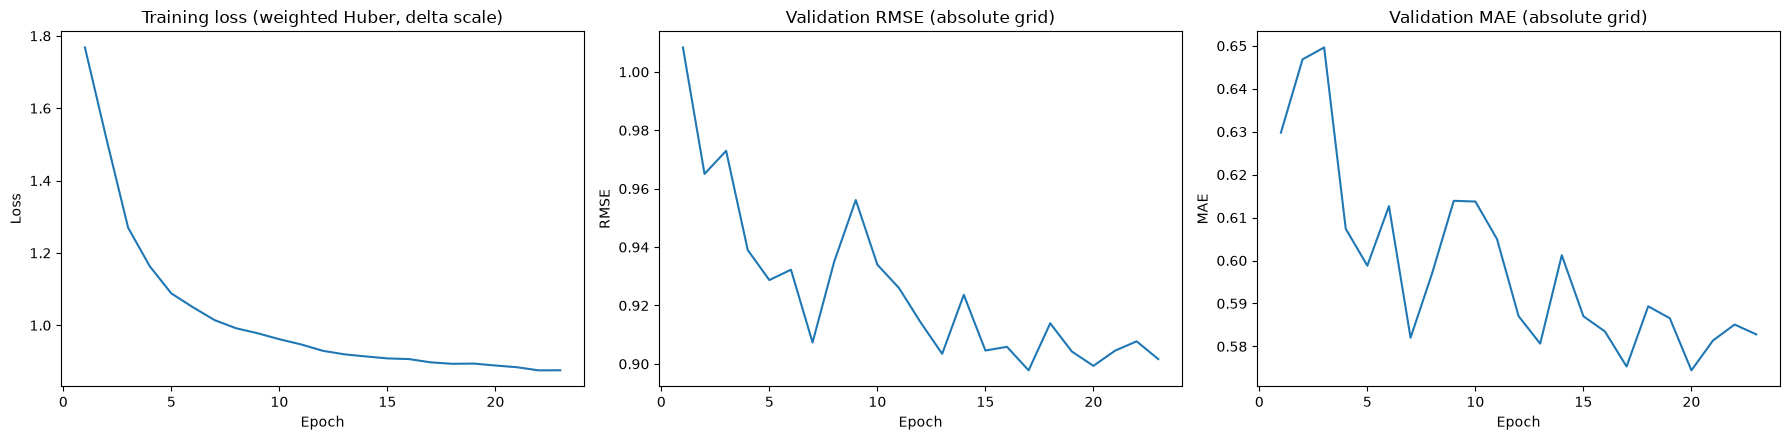

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history["epoch"], history["train_loss"])
axes[0].set_title("Training loss (weighted Huber, delta scale)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["epoch"], history["val_rmse"])
axes[1].set_title("Validation RMSE (absolute grid)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")

axes[2].plot(history["epoch"], history["val_mae"])
axes[2].set_title("Validation MAE (absolute grid)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")

plt.tight_layout()
plt.show()

## 12. Test evaluation

The persistence baseline (predict "no change from the last observed value")
is the number a delta model has to beat.

In [17]:
test_actuals, test_preds, test_last = predict(model, test_loader, delta_scaler, device)

test_metrics = calculate_metrics(test_actuals, test_preds)
baseline_metrics = calculate_metrics(test_actuals, test_last)

results = pd.DataFrame({"RSNN": test_metrics, "Persistence baseline": baseline_metrics}).T
display(results.round(4))

,MAE,RMSE,R2
RSNN,0.3476,0.6418,0.7808
Persistence baseline,0.3043,0.6896,0.7470


## 13. Test plots

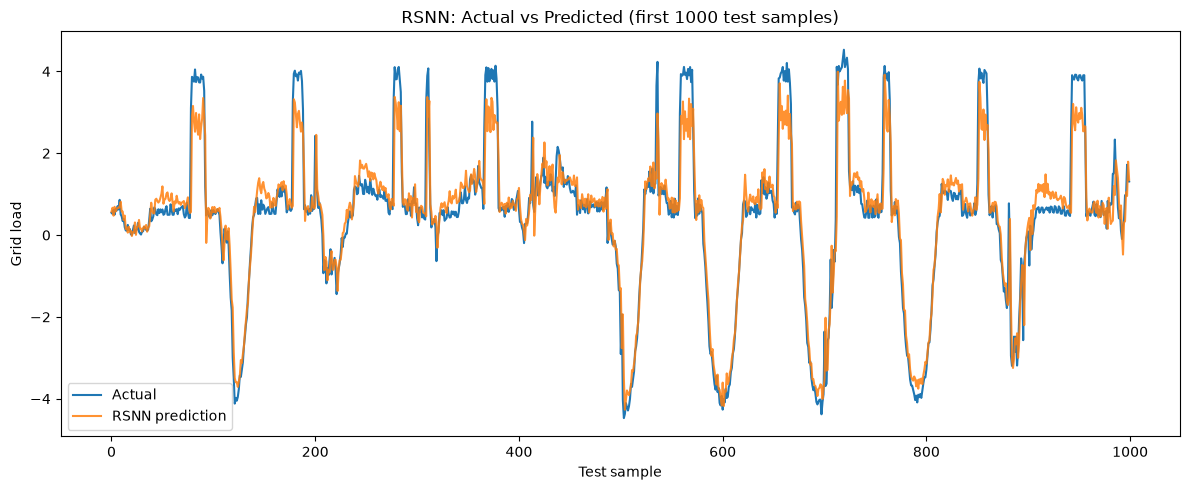

In [18]:
n = min(1000, len(test_actuals))

plt.figure(figsize=(12, 5))
plt.plot(test_actuals[:n], label="Actual")
plt.plot(test_preds[:n], label="RSNN prediction", alpha=0.85)
plt.xlabel("Test sample")
plt.ylabel("Grid load")
plt.title(f"RSNN: Actual vs Predicted (first {n} test samples)")
plt.legend()
plt.tight_layout()
plt.show()

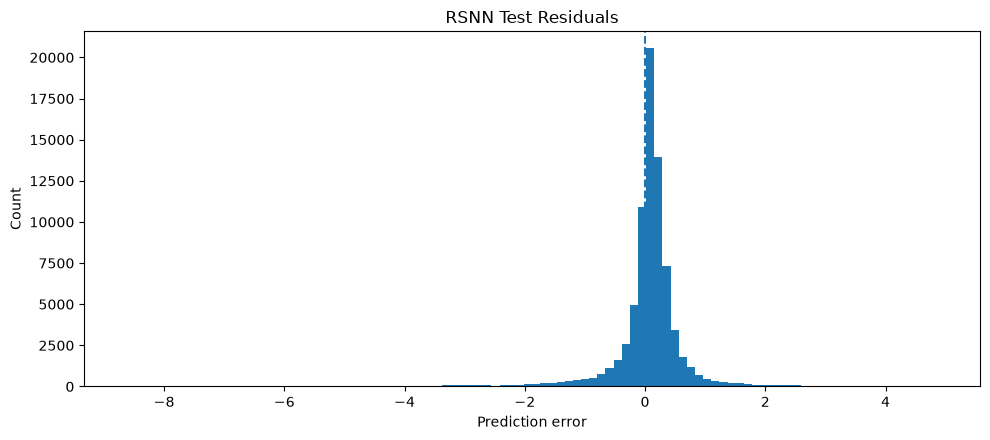

In [19]:
residuals = test_preds - test_actuals

plt.figure(figsize=(10, 4.5))
plt.hist(residuals, bins=100)
plt.axvline(0, linestyle="--")
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.title("RSNN Test Residuals")
plt.tight_layout()
plt.show()

## 14. Save model, metrics, history and predictions

Plots are intentionally not written to disk.

In [20]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_scaler": feature_scaler,
        "delta_scaler": delta_scaler,
        "home_to_idx": home_to_idx,
        "features": FEATURES,
        "target": TARGET,
        "window": WINDOW,
        "horizon": HORIZON,
    },
    RESULTS_DIR / "model.pt",
)

metrics = {
    "model": "RSNN_delta",
    "seed": SEED,
    "window": WINDOW,
    "horizon": HORIZON,
    "features": FEATURES,
    "target": f"{TARGET}_delta",
    "test": test_metrics,
    "persistence_baseline": baseline_metrics,
    "best_validation_rmse": best_val,
}

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame(history).to_csv(RESULTS_DIR / "training_history.csv", index=False)

pd.DataFrame(
    {"actual": test_actuals, "prediction": test_preds, "residual": residuals}
).to_csv(RESULTS_DIR / "predictions.csv", index=False)

print(f"Saved model, metrics, history and predictions to {RESULTS_DIR}/")

Saved model, metrics, history and predictions to results/rsnn/


In [21]:
import random
import numpy as np
import torch


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False